# Figure 1: Econometrics

## Objective
In this experiment, we analyze the evolution of negotiations developed by different models across a game using three key metrics:
1. **Utilitarian Social Welfare (USW)**
2. **Egalitarian Social Welfare (ESW)**
3. **Nash Social Welfare (NSW)**

These metrics help us evaluate the outcomes of the negotiations, with USW being the primary metric used in the original paper. ESW and NSW are introduced to ensure fairness in the negotiation process. The results of this experiment are referred as **Experiment 4** in our paper.

---

## Models
The following models are evaluated in this experiment:
- **Phi-3.5-mini**
- **gpt4o-mini**
- **Qwen2.5-72B**
- **DeepSeek-R1-Distill-Qwen-32B**

---

## Metrics
The metrics used to evaluate the negotiation outcomes are defined as follows:

1. **Utilitarian Social Welfare (USW)**  
   Measures the total utility across all participants:  
   $$
   S_{\mathrm{usw}}(\pi) = \sum_{p_i \in P} U_{p_i}(\pi)
   $$

2. **Egalitarian Social Welfare (ESW)**  
   Focuses on the minimum utility among participants to ensure fairness:  
   $$
   S_{\mathrm{esw}}(\pi) = \min_{p_i \in P} \bigl\{\,U_{p_i}(\pi)\bigr\}
   $$

3. **Nash Social Welfare (NSW)**  
   Balances fairness and efficiency by taking the product of all participants' utilities:  
   $$
   S_{\mathrm{nsw}}(\pi) = \prod_{p_i \in P} U_{p_i}(\pi)
   $$

---

## Results
The results of this experiment are visualized in **Figure 1** of our paper, showcasing the evolution of negotiations across the game for each model under the three metrics. This analysis provides insights into how well each model balances efficiency and fairness in negotiation scenarios.

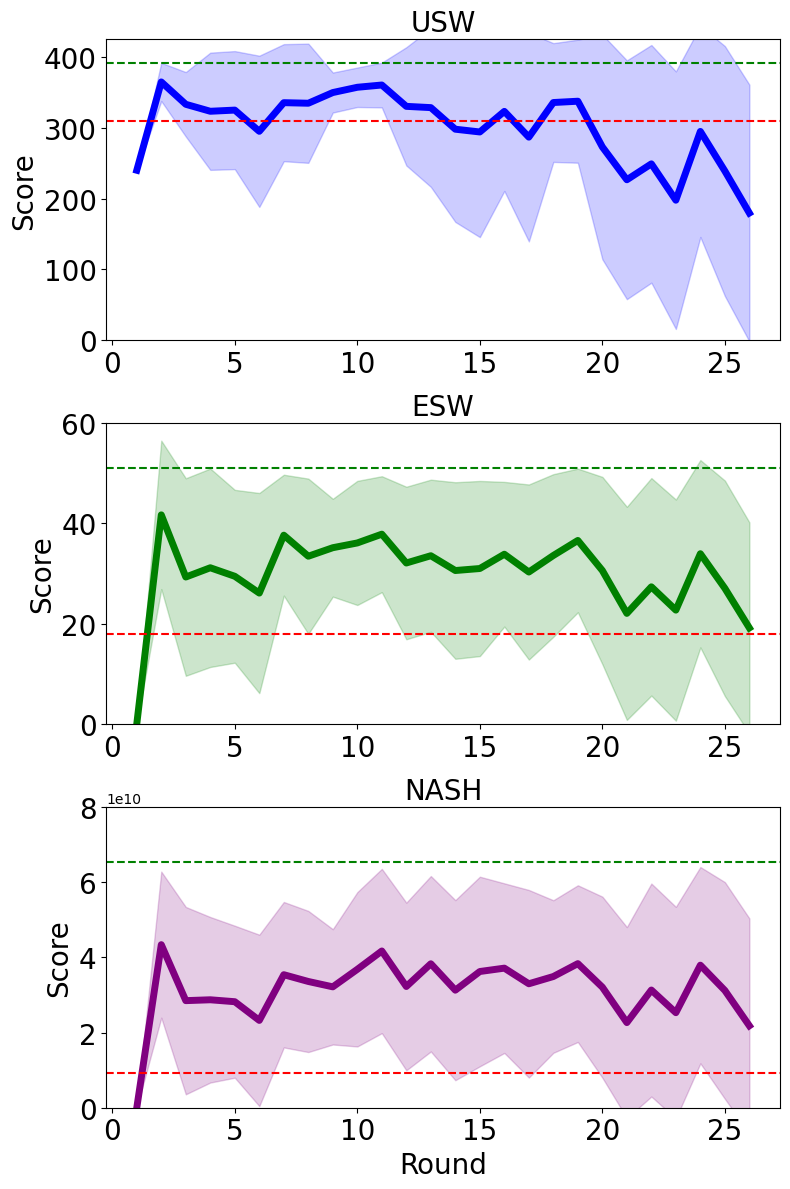

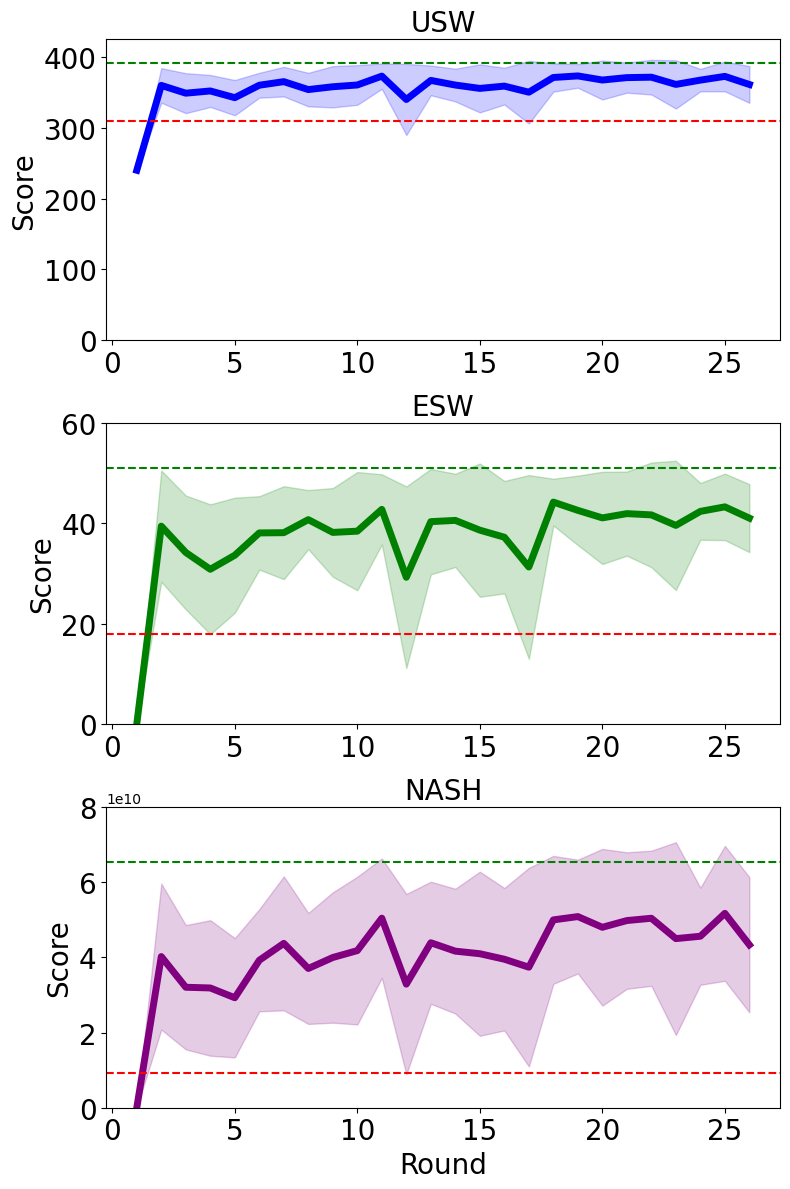

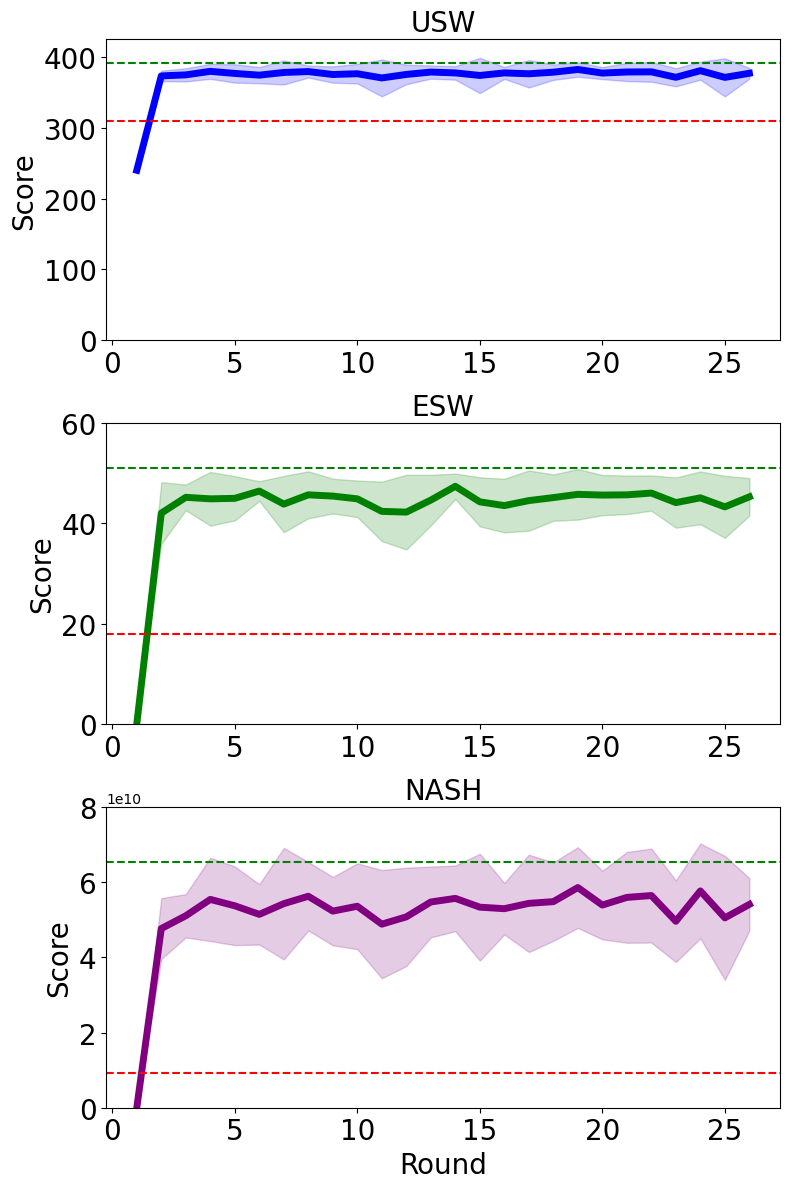

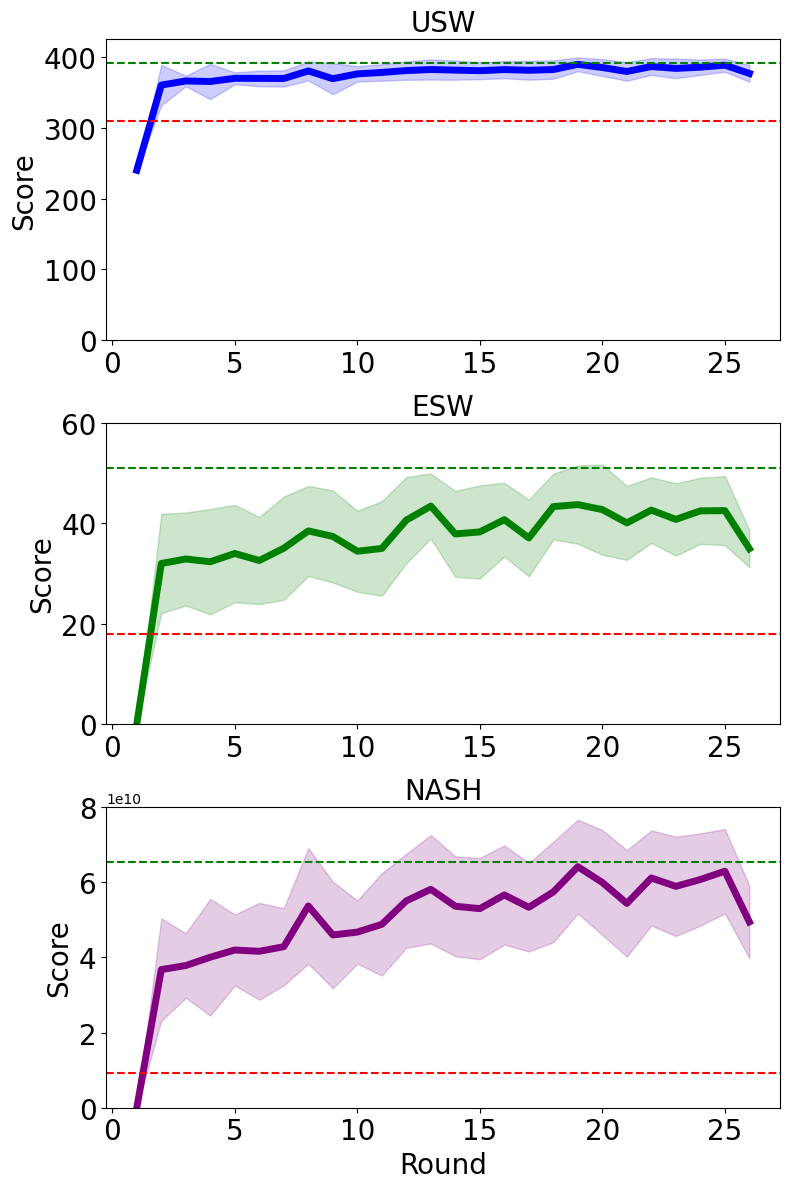

In [1]:
import os
import eval_utils as evaluation
import json
import numpy as np
import matplotlib.pyplot as plt

raw_path = '../our_games_descriptions/base/output/original_code'

models = ['Phi-3.5-mini-instruct', 'gpt4o-mini', 'Qwen2.5-72B-Instruct', 'DeepSeek-R1-Distill-Qwen-32B']

results = {}
ISSUES_NUM = 5
AGENTS_NUM = 6

for i, model in enumerate(models):

    directory = os.path.join(raw_path, model)
    agents, role_to_agents, incentive_to_agents = evaluation.load_setup(directory, AGENTS_NUM, num_issues=ISSUES_NUM)
    answers_files = [ os.path.join(directory,filename) for filename in os.listdir(directory) if filename.startswith("history")]

    if i == 0:
        # GAME INFORMATION - Pre Hoc: This is independent of the model so it is only computed once
        # The informations shown here is independent of the agent's performance and it only reflects inherent game statistics

        all_deals = evaluation.get_all_deals(agents)
        feasibility_set = evaluation.compute_feasibility_set(agents, all_deals)

        # Compute **social welfare metrics** for each deal
        usw_scores = [evaluation.compute_usw(deal, agents, ISSUES_NUM) for deal in all_deals]
        esw_scores = [evaluation.compute_esw(deal, agents, ISSUES_NUM) for deal in all_deals]
        nash_scores = [evaluation.compute_nash(deal, agents, ISSUES_NUM) for deal in all_deals]

        # Compute **minimal acceptable score** for each metric (minimum value of an accepted deal)
        feasible_usw = [evaluation.compute_usw(deal, agents, ISSUES_NUM) for deal in feasibility_set]
        feasible_esw = [evaluation.compute_esw(deal, agents, ISSUES_NUM) for deal in feasibility_set]
        feasible_nash = [evaluation.compute_nash(deal, agents, ISSUES_NUM) for deal in feasibility_set]

        min_usw = min(feasible_usw) if feasible_usw else 0
        min_esw = min(feasible_esw) if feasible_esw else 0
        min_nash = min(feasible_nash) if feasible_nash else 0

        max_usw = max(feasible_usw) if feasible_usw else 0
        max_esw = max(feasible_esw) if feasible_esw else 0
        max_nash = max(feasible_nash) if feasible_nash else 0


    # GAME INFORMATION - Post Hoc

    # Initialize lists to store scores per round across all games
    num_rounds = 0
    for file_ in answers_files:
        answers = json.load(open(file_))
        _num_rounds = len(answers['rounds'])
        num_rounds = max(num_rounds, _num_rounds)


    usw_scores, esw_scores, nash_scores = [], [], []

    # Loop through all answer files (each represents a game)
    for file_ in answers_files:
        answers = json.load(open(file_))
        
        if len(answers['rounds']) != num_rounds:
            print(f"Game {file_} has a different number of rounds")
            continue

        # Extract deals for this game
        game_usw, game_esw, game_nash = [], [], []
    
        
        for i, round_ in enumerate(answers['rounds']):
            name, answer = round_['agent'], round_['public_answer']
            deal_unformatted, issues_suggested = evaluation.extract_deal(answer, ISSUES_NUM)

            try:
                deal = evaluation.format_deal(deal_unformatted, ISSUES_NUM)
            except:
                print(f"Error in game {file_} round {i}")
                continue

            # Compute scores for this round
            usw = evaluation.compute_usw(deal, agents, ISSUES_NUM)
            esw = evaluation.compute_esw(deal, agents, ISSUES_NUM)
            nash = evaluation.compute_nash(deal, agents, ISSUES_NUM)

            game_usw.append(usw)
            game_esw.append(esw)
            game_nash.append(nash)

        # Store the game data
        usw_scores.append(game_usw)
        esw_scores.append(game_esw)
        nash_scores.append(game_nash)
    

    usw_scores, esw_scores, nash_scores = np.array(usw_scores), np.array(esw_scores), np.array(nash_scores)
    
    results[model] = {
        "mean_usw": np.mean(usw_scores, axis=0), "std_usw": np.std(usw_scores, axis=0),
        "mean_esw": np.mean(esw_scores, axis=0), "std_esw": np.std(esw_scores, axis=0),
        "mean_nash": np.mean(nash_scores, axis=0), "std_nash": np.std(nash_scores, axis=0)
    }

# Plotting
rounds = np.arange(1, num_rounds + 1)
model_positions = {"Phi-3.5-mini-instruct": 0, "gpt4o-mini": 1, "Qwen2.5-72B-Instruct": 2, "DeepSeek-R1-Distill-Qwen-32B": 3}

metrics = ["usw", "esw", "nash"]
colors = ["blue", "green", "purple"]

for model in models:
    fig, axes = plt.subplots(3, 1, figsize=(8, 12))
    
    for ax, metric, color in zip(axes, metrics, colors):
        ax.plot(rounds, results[model][f"mean_{metric}"], label=f"Mean {metric.upper()}", color=color, linewidth=5)
        ax.fill_between(rounds, results[model][f"mean_{metric}"] - results[model][f"std_{metric}"],
                         results[model][f"mean_{metric}"] + results[model][f"std_{metric}"], color=color, alpha=0.2)
        ax.axhline(globals()[f"min_{metric}"], color="red", linestyle="--", label=f"Min {metric.upper()}")
        ax.axhline(globals()[f"max_{metric}"], color="green", linestyle="--", label=f"Max {metric.upper()}")
        ax.set_title(f"{metric.upper()}", fontsize=20)
        ax.tick_params(axis='both', which='major', labelsize=20)
        ax.set_ylabel("Score", fontsize=20)
        if metric == "usw":
            ax.set_ylim(0, 425)
        elif metric == "esw":
            ax.set_ylim(0, 60)
        elif metric == "nash":
            ax.set_xlabel("Round", fontsize=20)
            ax.set_ylim(0, 8e10)
        # Increse gap between the subplots
        plt.subplots_adjust(hspace=0.5)
    
    plt.tight_layout()
plt.show()